In [1]:
from pathlib import Path
import math
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [7]:
DATA_PATH = Path("../../data/processed/economics/trend/suburb_monthly_market.parquet")

df = pd.read_parquet(DATA_PATH)
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["suburb", "postcode", "month"]).reset_index(drop=True)

print(df.shape)
print(df["month"].min(), "->", df["month"].max())
df.head()

(13177, 17)
2020-01-01 00:00:00 -> 2026-05-01 00:00:00


,suburb,postcode,month,sales_count,median_sale_price,mean_sale_price,p25_sale_price,p75_sale_price,log_median_sale_price,growth_1m,growth_3m,rolling_median_3m,rolling_median_6m,rolling_sales_count_3m,rolling_sales_count_6m,target_growth_3m,target_market_trend_multiplier
0,ABBOTSBURY,2176,2025-09-01,3,1830000.0,1.831667e+06,1805000.0,1857500.0,14.419827,NaN,NaN,1830000.0,1830000.0,3.0,3.0,-0.078700,0.924317
1,ABBOTSBURY,2176,2025-11-01,2,1975000.0,1.975000e+06,1912500.0,2037500.0,14.496079,0.076252,NaN,1902500.0,1902500.0,5.0,5.0,-0.062684,0.939241
2,ABBOTSBURY,2176,2025-12-01,2,1995000.0,1.995000e+06,1802500.0,2187500.0,14.506155,0.010076,NaN,1975000.0,1975000.0,7.0,7.0,0.058411,1.060150
3,ABBOTSBURY,2176,2026-01-01,1,1691500.0,1.691500e+06,1691500.0,1691500.0,14.341127,-0.165028,-0.078700,1975000.0,1902500.0,5.0,8.0,NaN,NaN
4,ABBOTSBURY,2176,2026-02-01,6,1855000.0,1.894167e+06,1787500.0,1918750.0,14.433396,0.092269,-0.062684,1855000.0,1855000.0,9.0,14.0,NaN,NaN


In [8]:
feature_cols = [
    "sales_count",
    "median_sale_price",
    "mean_sale_price",
    "p25_sale_price",
    "p75_sale_price",
    "log_median_sale_price",
    "growth_1m",
    "growth_3m",
    "rolling_median_3m",
    "rolling_median_6m",
    "rolling_sales_count_3m",
    "rolling_sales_count_6m",
]

target_col = "target_growth_3m"

work = df.copy()

for col in feature_cols + [target_col]:
    work[col] = pd.to_numeric(work[col], errors="coerce")

# Fill feature NaNs conservatively.
for col in feature_cols:
    if "growth" in col:
        work[col] = work[col].fillna(0.0)
    else:
        work[col] = work[col].fillna(work[col].median())

work = work[work[target_col].notna()].copy()

print(work.shape)
print("target range:", work[target_col].min(), work[target_col].max())
print("target mean:", work[target_col].mean())
print("target std:", work[target_col].std())

(6232, 17)
target range: -4.741722096740359 3.739635508999106
target mean: -0.14487502087415638
target std: 0.6859988250835727


In [9]:
SEQ_LEN = 6

def build_sequences(df, feature_cols, target_col, seq_len=6):
    X_list = []
    y_list = []
    meta_list = []

    for (suburb, postcode), g in df.groupby(["suburb", "postcode"], sort=False):
        g = g.sort_values("month").reset_index(drop=True)

        if len(g) <= seq_len:
            continue

        features = g[feature_cols].to_numpy(dtype=np.float32)
        targets = g[target_col].to_numpy(dtype=np.float32)
        months = g["month"].to_numpy()

        for i in range(seq_len, len(g)):
            X_list.append(features[i-seq_len:i])
            y_list.append(targets[i])
            meta_list.append({
                "suburb": suburb,
                "postcode": postcode,
                "month": pd.Timestamp(months[i]),
            })

    X = np.stack(X_list) if X_list else np.empty((0, seq_len, len(feature_cols)), dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

X, y, meta = build_sequences(work, feature_cols, target_col, SEQ_LEN)

print("X:", X.shape)
print("y:", y.shape)
print(meta.head())
print(meta["month"].min(), "->", meta["month"].max())

X: (694, 6, 12)
y: (694,)
      suburb postcode      month
0  ADAMSTOWN     2289 2025-10-01
1  ADAMSTOWN     2289 2025-11-01
2  ADAMSTOWN     2289 2025-12-01
3  ADAMSTOWN     2289 2026-01-01
4  ADAMSTOWN     2289 2026-02-01
2021-08-01 00:00:00 -> 2026-02-01 00:00:00


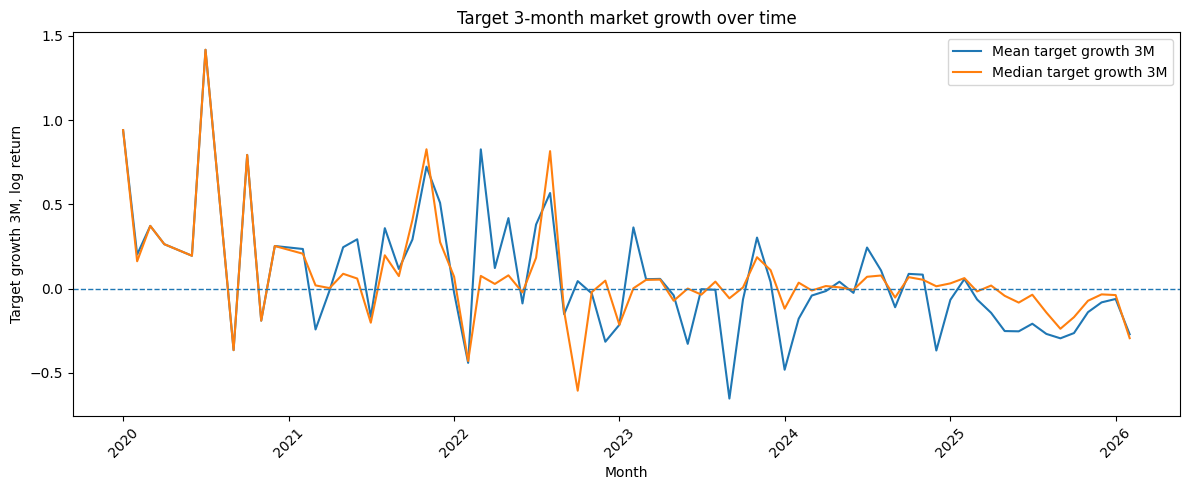

In [14]:
import matplotlib.pyplot as plt

plot_df = work.copy()
plot_df["month"] = pd.to_datetime(plot_df["month"])

monthly_y = (
    plot_df.groupby("month", as_index=False)
    .agg(
        mean_target_growth_3m=("target_growth_3m", "mean"),
        median_target_growth_3m=("target_growth_3m", "median"),
        sample_count=("target_growth_3m", "size"),
    )
    .sort_values("month")
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_y["month"], monthly_y["mean_target_growth_3m"], label="Mean target growth 3M")
plt.plot(monthly_y["month"], monthly_y["median_target_growth_3m"], label="Median target growth 3M")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Target 3-month market growth over time")
plt.xlabel("Month")
plt.ylabel("Target growth 3M, log return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
split_month = meta["month"].quantile(0.8)
split_month

Timestamp('2026-01-01 00:00:00')

In [16]:
train_mask = meta["month"] <= split_month
test_mask = meta["month"] > split_month

X_train, y_train = X[train_mask.to_numpy()], y[train_mask.to_numpy()]
X_test, y_test = X[test_mask.to_numpy()], y[test_mask.to_numpy()]
meta_train, meta_test = meta[train_mask].copy(), meta[test_mask].copy()

print("train:", X_train.shape, y_train.shape, meta_train["month"].min(), meta_train["month"].max())
print("test:", X_test.shape, y_test.shape, meta_test["month"].min(), meta_test["month"].max())

train: (649, 6, 12) (649,) 2021-08-01 00:00:00 2026-01-01 00:00:00
test: (45, 6, 12) (45,) 2026-02-01 00:00:00 2026-02-01 00:00:00


In [17]:
n_features = X_train.shape[-1]

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape).astype(np.float32)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape).astype(np.float32)

In [18]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = SequenceDataset(X_train_scaled, y_train)
test_ds = SequenceDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [19]:
class MarketTrendLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, dropout=0.1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)


model = MarketTrendLSTM(
    input_dim=len(feature_cols),
    hidden_dim=32,
    num_layers=1,
    dropout=0.1,
).to(device)

model

MarketTrendLSTM(
  (lstm): LSTM(12, 32, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [20]:
def evaluate(model, loader):
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            preds.append(pred.cpu().numpy().reshape(-1))
            targets.append(yb.cpu().numpy().reshape(-1))

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    mae = mean_absolute_error(targets, preds)
    rmse = mean_squared_error(targets, preds, squared=False)

    direction_acc = np.mean(np.sign(preds) == np.sign(targets))

    return {
        "mae": mae,
        "rmse": rmse,
        "direction_acc": direction_acc,
        "preds": preds,
        "targets": targets,
    }

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()

best_test_mae = float("inf")
best_state = None

history = []

EPOCHS = 50

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_fn(pred, yb)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_losses.append(loss.item())

    train_eval = evaluate(model, train_loader)
    test_eval = evaluate(model, test_loader)

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "train_mae": train_eval["mae"],
        "test_mae": test_eval["mae"],
        "test_rmse": test_eval["rmse"],
        "test_direction_acc": test_eval["direction_acc"],
    }
    history.append(row)

    if test_eval["mae"] < best_test_mae:
        best_test_mae = test_eval["mae"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(row)

model.load_state_dict(best_state)

/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated i

{'epoch': 1, 'train_loss': 0.16067428683692758, 'train_mae': np.float32(0.3801228), 'test_mae': np.float32(0.52661884), 'test_rmse': np.float32(0.7555955), 'test_direction_acc': np.float64(0.5777777777777777)}


/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated i

{'epoch': 5, 'train_loss': 0.1680200303142721, 'train_mae': np.float32(0.37818208), 'test_mae': np.float32(0.54459244), 'test_rmse': np.float32(0.77062076), 'test_direction_acc': np.float64(0.3333333333333333)}


/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated i

...

{'epoch': 40, 'train_loss': 0.12887913936918433, 'train_mae': np.float32(0.35805047), 'test_mae': np.float32(0.5379271), 'test_rmse': np.float32(0.787158), 'test_direction_acc': np.float64(0.4444444444444444)}


/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated i

{'epoch': 45, 'train_loss': 0.13037510893561624, 'train_mae': np.float32(0.35264677), 'test_mae': np.float32(0.53712445), 'test_rmse': np.float32(0.78927064), 'test_direction_acc': np.float64(0.5111111111111111)}
{'epoch': 50, 'train_loss': 0.13886307992718436, 'train_mae': np.float32(0.3515822), 'test_mae': np.float32(0.54302496), 'test_rmse': np.float32(0.788858), 'test_direction_acc': np.float64(0.4888888888888889)}


/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated i

<All keys matched successfully>

In [21]:
zero_pred = np.zeros_like(y_test)

zero_mae = mean_absolute_error(y_test, zero_pred)
zero_rmse = mean_squared_error(y_test, zero_pred, squared=False)
zero_direction_acc = np.mean(np.sign(zero_pred) == np.sign(y_test))

{
    "zero_mae": zero_mae,
    "zero_rmse": zero_rmse,
    "zero_direction_acc": zero_direction_acc,
}

/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'zero_mae': np.float32(0.5335375),
 'zero_rmse': np.float32(0.7649825),
 'zero_direction_acc': np.float64(0.0)}

In [22]:
growth_3m_idx = feature_cols.index("growth_3m")
momentum_pred = X_test[:, -1, growth_3m_idx]

# Clamp like production.
momentum_pred = np.clip(momentum_pred, -0.04, 0.04)

momentum_mae = mean_absolute_error(y_test, momentum_pred)
momentum_rmse = mean_squared_error(y_test, momentum_pred, squared=False)
momentum_direction_acc = np.mean(np.sign(momentum_pred) == np.sign(y_test))

{
    "momentum_mae": momentum_mae,
    "momentum_rmse": momentum_rmse,
    "momentum_direction_acc": momentum_direction_acc,
}

/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'momentum_mae': np.float32(0.532051),
 'momentum_rmse': np.float32(0.7592783),
 'momentum_direction_acc': np.float64(0.5111111111111111)}

In [23]:
lstm_eval = evaluate(model, test_loader)

lstm_pred = lstm_eval["preds"]
lstm_pred_clamped = np.clip(lstm_pred, -0.04, 0.04)

lstm_mae = mean_absolute_error(y_test, lstm_pred_clamped)
lstm_rmse = mean_squared_error(y_test, lstm_pred_clamped, squared=False)
lstm_direction_acc = np.mean(np.sign(lstm_pred_clamped) == np.sign(y_test))

{
    "lstm_mae": lstm_mae,
    "lstm_rmse": lstm_rmse,
    "lstm_direction_acc": lstm_direction_acc,
}

/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'lstm_mae': np.float32(0.53088903),
 'lstm_rmse': np.float32(0.76347125),
 'lstm_direction_acc': np.float64(0.5777777777777777)}

In [25]:
{
    "model1": "zero_growth",
    "mae1": zero_mae,
    "rmse1": zero_rmse,
    "direction_acc1": zero_direction_acc,
    "model2": "latest_growth_3m_momentum",
    "mae2": momentum_mae,
    "rmse2": momentum_rmse,
    "direction_acc2": momentum_direction_acc,
    "model3": "lstm_clamped",
    "mae3": lstm_mae,
    "rmse3": lstm_rmse,
    "direction_acc3": lstm_direction_acc,

}

{'model1': 'zero_growth',
 'mae1': np.float32(0.5335375),
 'rmse1': np.float32(0.7649825),
 'direction_acc1': np.float64(0.0),
 'model2': 'latest_growth_3m_momentum',
 'mae2': np.float32(0.532051),
 'rmse2': np.float32(0.7592783),
 'direction_acc2': np.float64(0.5111111111111111),
 'model3': 'lstm_clamped',
 'mae3': np.float32(0.53088903),
 'rmse3': np.float32(0.76347125),
 'direction_acc3': np.float64(0.5777777777777777)}

# Rolling Window Regression

In [26]:
reg_df = work.copy()
reg_df["month"] = pd.to_datetime(reg_df["month"])

for col in feature_cols + [target_col]:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

reg_df = reg_df[reg_df[target_col].notna()].copy()

# Clip target to reduce transaction-mix outlier impact.
# 3-month log growth beyond +/- 30% is very likely noisy for suburb-level median.
TARGET_CLIP = 0.30
reg_df["target_growth_3m_clipped"] = reg_df[target_col].clip(-TARGET_CLIP, TARGET_CLIP)

print(reg_df[target_col].describe())
print(reg_df["target_growth_3m_clipped"].describe())

count    6232.000000
mean       -0.144875
std         0.685999
min        -4.741722
25%        -0.365574
50%        -0.065312
75%         0.139275
max         3.739636
Name: target_growth_3m, dtype: float64
count    6232.000000
mean       -0.048716
std         0.223336
min        -0.300000
25%        -0.300000
50%        -0.065312
75%         0.139275
max         0.300000
Name: target_growth_3m_clipped, dtype: float64


In [28]:
reg_df = reg_df.sort_values(["suburb", "postcode", "month"]).copy()

group_cols = ["suburb", "postcode"]

for lag in [1, 2, 3]:
    reg_df[f"lag_growth_1m_{lag}"] = (
        reg_df.groupby(group_cols)["growth_1m"].shift(lag)
    )
    reg_df[f"lag_growth_3m_{lag}"] = (
        reg_df.groupby(group_cols)["growth_3m"].shift(lag)
    )
    reg_df[f"lag_log_price_{lag}"] = (
        reg_df.groupby(group_cols)["log_median_sale_price"].shift(lag)
    )
    reg_df[f"lag_sales_count_{lag}"] = (
        reg_df.groupby(group_cols)["sales_count"].shift(lag)
    )

reg_df["rolling_growth_1m_mean_3"] = (
    reg_df.groupby(group_cols)["growth_1m"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

reg_df["rolling_growth_3m_mean_3"] = (
    reg_df.groupby(group_cols)["growth_3m"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

reg_df["rolling_sales_count_mean_3"] = (
    reg_df.groupby(group_cols)["sales_count"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

regression_features = [
    "sales_count",
    "median_sale_price",
    "log_median_sale_price",
    "growth_1m",
    "growth_3m",
    "rolling_median_3m",
    "rolling_median_6m",
    "rolling_sales_count_3m",
    "rolling_sales_count_6m",
    "lag_growth_1m_1",
    "lag_growth_1m_2",
    "lag_growth_1m_3",
    "lag_growth_3m_1",
    "lag_growth_3m_2",
    "lag_growth_3m_3",
    "lag_log_price_1",
    "lag_log_price_2",
    "lag_log_price_3",
    "lag_sales_count_1",
    "lag_sales_count_2",
    "lag_sales_count_3",
    "rolling_growth_1m_mean_3",
    "rolling_growth_3m_mean_3",
    "rolling_sales_count_mean_3",
]

for col in regression_features:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

reg_df[regression_features] = (
    reg_df[regression_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

print(reg_df.shape)
reg_df[["suburb", "postcode", "month", "target_growth_3m_clipped"] + regression_features[:8]].head()

(6232, 33)


,suburb,postcode,month,target_growth_3m_clipped,sales_count,median_sale_price,log_median_sale_price,growth_1m,growth_3m,rolling_median_3m,rolling_median_6m,rolling_sales_count_3m
0,ABBOTSBURY,2176,2025-09-01,-0.078700,3,1830000.0,14.419827,0.000000,0.0,1830000.0,1830000.0,3.0
1,ABBOTSBURY,2176,2025-11-01,-0.062684,2,1975000.0,14.496079,0.076252,0.0,1902500.0,1902500.0,5.0
2,ABBOTSBURY,2176,2025-12-01,0.058411,2,1995000.0,14.506155,0.010076,0.0,1975000.0,1975000.0,7.0
6,ABBOTSFORD,2046,2025-07-01,-0.300000,1,7200000.0,15.789592,0.000000,0.0,7200000.0,7200000.0,1.0
7,ABBOTSFORD,2046,2025-10-01,-0.300000,4,3640000.0,15.107495,-0.682097,0.0,5420000.0,5420000.0,5.0


In [29]:
split_month = reg_df["month"].quantile(0.8)

train_df = reg_df[reg_df["month"] <= split_month].copy()
test_df = reg_df[reg_df["month"] > split_month].copy()

print("split:", split_month)
print("train:", train_df.shape, train_df["month"].min(), train_df["month"].max())
print("test:", test_df.shape, test_df["month"].min(), test_df["month"].max())

split: 2025-12-01 00:00:00
train: (5312, 33) 2020-01-01 00:00:00 2025-12-01 00:00:00
test: (920, 33) 2026-01-01 00:00:00 2026-02-01 00:00:00


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

X_train = train_df[regression_features].to_numpy(dtype=np.float32)
y_train = train_df["target_growth_3m_clipped"].to_numpy(dtype=np.float32)

X_test = test_df[regression_features].to_numpy(dtype=np.float32)
y_test = test_df["target_growth_3m_clipped"].to_numpy(dtype=np.float32)

models = {
    "zero_growth": None,
    "latest_growth_3m": None,
    "ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0)),
    ]),
    "huber": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HuberRegressor(epsilon=1.35, alpha=0.001, max_iter=1000)),
    ]),
    "hist_gbr": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.04,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42,
    ),
    "random_forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
    ),
}

def evaluate_preds(name, preds, y_true):
    preds = np.asarray(preds, dtype=float)
    preds = np.clip(preds, -0.04, 0.04)

    return {
        "model": name,
        "mae": mean_absolute_error(y_true, preds),
        "rmse": mean_squared_error(y_true, preds, squared=False),
        "direction_acc": np.mean(np.sign(preds) == np.sign(y_true)),
        "pred_mean": float(np.mean(preds)),
        "pred_std": float(np.std(preds)),
    }

rows = []

# Baseline 1
rows.append(evaluate_preds("zero_growth", np.zeros_like(y_test), y_test))

# Baseline 2
latest_growth = test_df["growth_3m"].fillna(0.0).to_numpy(dtype=float)
rows.append(evaluate_preds("latest_growth_3m", latest_growth, y_test))

for name, model in models.items():
    if model is None:
        continue
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rows.append(evaluate_preds(name, preds, y_test))

comparison_reg = pd.DataFrame(rows).sort_values("mae")
comparison_reg

/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated i

,model,mae,rmse,direction_acc,pred_mean,pred_std
4,hist_gbr,0.187983,0.215384,0.638043,0.001883,0.035100
5,random_forest,0.188008,0.215252,0.619565,-0.000583,0.036322
2,ridge,0.188041,0.214523,0.622826,-0.000260,0.033071
3,huber,0.188345,0.214849,0.616304,-0.000136,0.034064
0,zero_growth,0.196125,0.223749,0.002174,0.000000,0.000000
1,latest_growth_3m,0.201111,0.230583,0.367391,-0.010604,0.033075


In [31]:
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def rolling_walk_forward_eval(
    df,
    feature_cols,
    target_col,
    model,
    min_train_months=12,
    train_window_months=24,
):
    df = df.sort_values("month").copy()
    months = sorted(df["month"].dropna().unique())

    rows = []

    for test_month in months[min_train_months:]:
        train_start = pd.Timestamp(test_month) - pd.DateOffset(months=train_window_months)

        train = df[
            (df["month"] < test_month)
            & (df["month"] >= train_start)
        ].copy()

        test = df[df["month"] == test_month].copy()

        if len(train) < 200 or len(test) < 10:
            continue

        X_train = train[feature_cols].to_numpy(dtype=np.float32)
        y_train = train[target_col].to_numpy(dtype=np.float32)

        X_test = test[feature_cols].to_numpy(dtype=np.float32)
        y_test = test[target_col].to_numpy(dtype=np.float32)

        m = clone(model)
        m.fit(X_train, y_train)

        pred = m.predict(X_test)
        pred = np.clip(pred, -0.04, 0.04)

        for i, (_, row) in enumerate(test.iterrows()):
            rows.append({
                "month": row["month"],
                "suburb": row["suburb"],
                "postcode": row["postcode"],
                "actual": float(y_test[i]),
                "pred": float(pred[i]),
            })

    pred_df = pd.DataFrame(rows)

    if pred_df.empty:
        return pred_df, {}

    metrics = {
        "mae": mean_absolute_error(pred_df["actual"], pred_df["pred"]),
        "rmse": mean_squared_error(pred_df["actual"], pred_df["pred"], squared=False),
        "direction_acc": np.mean(np.sign(pred_df["actual"]) == np.sign(pred_df["pred"])),
        "n": len(pred_df),
        "months": pred_df["month"].nunique(),
    }

    return pred_df, metrics


rolling_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0)),
])

rolling_pred_df, rolling_metrics = rolling_walk_forward_eval(
    reg_df,
    regression_features,
    "target_growth_3m_clipped",
    rolling_model,
    min_train_months=12,
    train_window_months=24,
)

rolling_metrics

/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'mae': np.float64(0.188324855786807),
 'rmse': np.float64(0.21314624055491105),
 'direction_acc': np.float64(0.6856611430503889),
 'n': 5914,
 'months': 22}

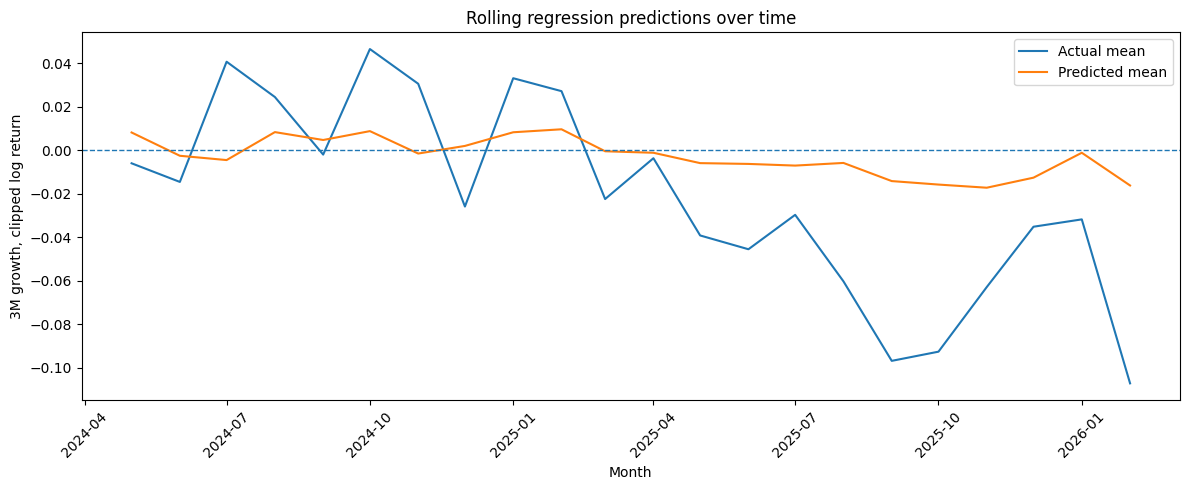

In [32]:
import matplotlib.pyplot as plt

if not rolling_pred_df.empty:
    monthly_pred = (
        rolling_pred_df.groupby("month", as_index=False)
        .agg(
            actual_mean=("actual", "mean"),
            pred_mean=("pred", "mean"),
            actual_median=("actual", "median"),
            pred_median=("pred", "median"),
            n=("actual", "size"),
        )
    )

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_pred["month"], monthly_pred["actual_mean"], label="Actual mean")
    plt.plot(monthly_pred["month"], monthly_pred["pred_mean"], label="Predicted mean")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Rolling regression predictions over time")
    plt.xlabel("Month")
    plt.ylabel("3M growth, clipped log return")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    monthly_pred

In [33]:
rolling_pred_df[["actual", "pred"]].describe()

,actual,pred
count,5914.000000,5914.000000
mean,-0.052685,-0.010469
std,0.222355,0.034222
min,-0.300000,-0.040000
25%,-0.300000,-0.040000
50%,-0.071227,-0.032614
75%,0.133531,0.034403
max,0.300000,0.040000


In [34]:
print("pred <= -0.04:", (rolling_pred_df["pred"] <= -0.04).mean())
print("pred >= 0.04:", (rolling_pred_df["pred"] >= 0.04).mean())

pred <= -0.04: 0.0
pred >= 0.04: 0.0


In [36]:
rolling_pred_df["pred_calibrated"] = np.clip(
    rolling_pred_df["pred"] * 1.5,
    -0.04,
    0.04,
)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = rolling_pred_df["actual"].to_numpy()
pred = rolling_pred_df["pred"].to_numpy()
pred_cal = rolling_pred_df["pred_calibrated"].to_numpy()

{
    "raw_mae": mean_absolute_error(actual, pred),
    "raw_rmse": mean_squared_error(actual, pred, squared=False),
    "raw_direction_acc": np.mean(np.sign(actual) == np.sign(pred)),

    "cal_mae": mean_absolute_error(actual, pred_cal),
    "cal_rmse": mean_squared_error(actual, pred_cal, squared=False),
    "cal_direction_acc": np.mean(np.sign(actual) == np.sign(pred_cal)),

    "raw_pred_mean": pred.mean(),
    "cal_pred_mean": pred_cal.mean(),
    "actual_mean": actual.mean(),
}

/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/kennyyu/smart-developer/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'raw_mae': np.float64(0.188324855786807),
 'raw_rmse': np.float64(0.21314624055491105),
 'raw_direction_acc': np.float64(0.6856611430503889),
 'cal_mae': np.float64(0.18834939660649896),
 'cal_rmse': np.float64(0.21317315360765554),
 'cal_direction_acc': np.float64(0.6856611430503889),
 'raw_pred_mean': np.float64(-0.010469387659583076),
 'cal_pred_mean': np.float64(-0.010771964207339299),
 'actual_mean': np.float64(-0.05268466157772446)}

In [38]:
tmp = rolling_pred_df.copy()
tmp["actual_sign"] = np.sign(tmp["actual"])
tmp["pred_sign"] = np.sign(tmp["pred"])
pos = tmp[tmp["actual_sign"] > 0]
neg = tmp[tmp["actual_sign"] < 0]
print("positive actual count:", len(pos))
print("positive direction acc:", (pos["pred_sign"] > 0).mean())
print("negative actual count:", len(neg))
print("negative direction acc:", (neg["pred_sign"] < 0).mean())

positive actual count: 2374
positive direction acc: 0.5606571187868576
negative actual count: 3505
negative direction acc: 0.7771754636233952
